# Hadronizing from the saved hydro history vs. MUSIC's full freeze-out surface

**Question.** The FNO training data (`run_prod_jet.py` pair files) keep only the *hydro
history*: $e, v_x, v_y, v_z$ on the output grid (0.3125 fm × 0.3125 fm × 0.3125 in
$\eta_s$, every 0.1 fm/c), no viscous fields. If an FNO predicts such a history, the
hadrons have to come from a freeze-out surface **found in that history** and sampled
**without viscous corrections**. How different are these hadrons from the correct ones,
i.e. iSS on MUSIC's own surface with $\pi^{\mu\nu}$ and $\Pi$ (`--write-particlize`)?

**Variants** (all hadronized with the same `hadronize.py` settings and seeds as the
reference; see `README.md` for how to reproduce them):

| variant | surface | viscous corrections |
|---|---|---|
| `ref` | MUSIC's (native grid, 0.3 fm × 0.2 in $\eta_s$, $\Delta\tau$ = 0.1) | $\pi^{\mu\nu}$ and $\Pi$ (shear + bulk $\delta f$) |
| `ref_no_shear` | MUSIC's | $\Pi$ only |
| `ref_no_bulk` | MUSIC's | $\pi^{\mu\nu}$ only |
| `ref_ideal` | MUSIC's | none |
| `hist` | Cornelius on the saved history (X-SCAPE `SurfaceFinder`, T from MUSIC's EoS 9) | none |

The chain `ref → ref_ideal → hist` splits the total difference `hist − ref` into the
**viscous part** (`ref_ideal − ref`, further split into shear and bulk) and the
**history part** (`hist − ref_ideal`: coarse grid, interpolation, missing |η_s| > 5).

**Statistics.** Every event is one fluid; its hadrons are the mean over its iSS
oversamples. Errors are the spread over events / √N_events. Differences between variants
are taken **event by event** (same fluid, same seeds, correlated sampling), so their errors
are much smaller than those of the variants themselves.

In [1]:
import json, os
import numpy as np
import matplotlib.pyplot as plt

SUMMARY = os.environ.get(
    "HVS_SUMMARY",
    "/home/putschke/FNO_Hydro_Data/AuAu_0_10_h5_pair_surface_test/hist_vs_surface/summary.npz")
S = np.load(SUMMARY)
meta = json.loads(str(S["meta"]))
E = {k.split("/", 1)[1]: S[k] for k in S.files if k.startswith("edges/")}
VARIANTS = [v for v in ("ref", "ref_no_shear", "ref_no_bulk", "ref_ideal", "hist")
            if f"had/{v}/jet/dndeta" in S.files]
NEV = len(S["jet/phi"])

# fixed identity per variant: colour (validated categorical slots) + line style
STYLE = {
    "ref":          dict(color="#222222", ls="-",  label="ref (MUSIC surface, viscous)"),
    "hist":         dict(color="#2a78d6", ls="-",  label="hist (saved history, ideal)"),
    "ref_ideal":    dict(color="#eb6834", ls="--", label="ref_ideal (MUSIC surface, no δf)"),
    "ref_no_bulk":  dict(color="#1baf7a", ls="-.", label="ref_no_bulk (Π = 0)"),
    "ref_no_shear": dict(color="#4a3aa7", ls=":",  label="ref_no_shear (π = 0)"),
}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "lines.linewidth": 2, "legend.frameon": False, "font.size": 10})

def had(v, leg, name):
    return S[f"had/{v}/{leg}/{name}"]

def surf(v, leg, name):
    return S[f"surf/{v}/{leg}/{name}"]

def mean_err(x):
    x = np.asarray(x, dtype=float)
    n = np.sum(np.isfinite(x), axis=0)
    return np.nanmean(x, axis=0), np.nanstd(x, axis=0, ddof=1) / np.sqrt(np.maximum(n, 1))

def rel_shift(x, x_ref):
    # (<x> - <x_ref>) / <x_ref>, error from the event-by-event differences
    d = np.asarray(x, float) - np.asarray(x_ref, float)
    m, e = mean_err(d)
    r = np.nanmean(np.asarray(x_ref, float), axis=0)
    return m / r, e / r

def centers(ed):
    return 0.5 * (ed[1:] + ed[:-1])

print(f"{SUMMARY}\n{NEV} events from {len(meta['stems'])} production files: "
      + ", ".join(os.path.basename(s) for s in meta["stems"]))
print("variants:", VARIANTS)
for v, m in meta["variants"].items():
    st = m.get("settings", {})
    if st:
        extra = {k: st[k] for k in ("lattice", "cap", "T_sw", "zeroed_columns") if k in st}
        print(f"  {v:13s} {extra}")
ha = meta["hadron_attrs"]["ref/bulk_jet"][0]
print("hadronization (reference):", {k: ha.get(k) for k in
      ("n_samples", "base_seed", "correlated_sampling", "seed_scheme")})

/home/putschke/FNO_Hydro_Data/AuAu_0_10_h5_pair_surface_test/hist_vs_surface/summary.npz
100 events from 4 production files: AuAu_0_10_jet_seed0001, AuAu_0_10_jet_seed0002, AuAu_0_10_jet_seed0003, AuAu_0_10_jet_seed0004
variants: ['ref', 'ref_no_shear', 'ref_no_bulk', 'ref_ideal', 'hist']
  ref_ideal     {'T_sw': 0.15, 'zeroed_columns': ['pi00', 'pi01', 'pi02', 'pi03', 'pi11', 'pi12', 'pi13', 'pi22', 'pi23', 'pi33', 'Pi']}
  ref_no_bulk   {'T_sw': 0.15, 'zeroed_columns': ['Pi']}
  ref_no_shear  {'T_sw': 0.15, 'zeroed_columns': ['pi00', 'pi01', 'pi02', 'pi03', 'pi11', 'pi12', 'pi13', 'pi22', 'pi23', 'pi33']}
  hist          {'lattice': [0.1, 0.3125, 0.3125], 'cap': True, 'T_sw': 0.15}
hadronization (reference): {'n_samples': 100, 'base_seed': 1, 'correlated_sampling': True, 'seed_scheme': 'production_file'}


## 1. The surfaces

Before any hadron: how does the surface found in the saved history compare with MUSIC's?
The volume $V = \int d^3\sigma_\mu u^\mu$ counts the fluid that freezes out; its
distribution in $\tau$, $\eta_s$ and transverse flow $u_T$ shows where the two differ.
Only `ref` and `hist` have their own geometry (the `ref_*` variants reuse `ref`'s).

bg : V_hist / V_ref = 0.9809 ± 0.0000 (events 0.980 .. 0.982);  cells hist/ref = 0.696;  negative V: ref -0.0002, hist -0.0003
jet: V_hist / V_ref = 0.9807 ± 0.0000 (events 0.980 .. 0.982);  cells hist/ref = 0.696;  negative V: ref -0.0003, hist -0.0003


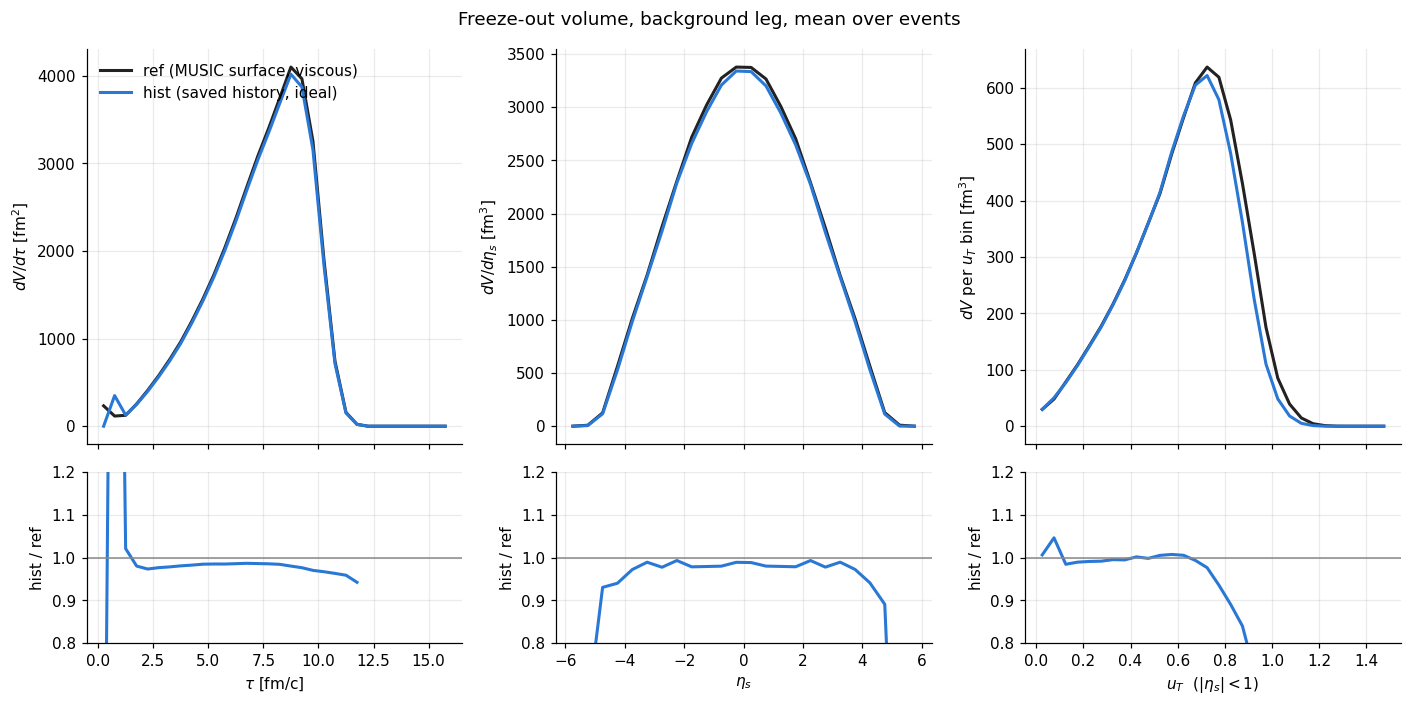

In [2]:
if "surf/hist/bg/V" in S.files:
    for leg in ("bg", "jet"):
        r = surf("hist", leg, "V") / surf("ref", leg, "V")
        n = surf("hist", leg, "n_cells") / surf("ref", leg, "n_cells")
        print(f"{leg:3s}: V_hist / V_ref = {r.mean():.4f} ± {r.std(ddof=1)/np.sqrt(len(r)):.4f}"
              f" (events {r.min():.3f} .. {r.max():.3f});  cells hist/ref = {n.mean():.3f};"
              f"  negative V: ref {np.mean(surf('ref', leg, 'V_neg') / surf('ref', leg, 'V')):.4f},"
              f" hist {np.mean(surf('hist', leg, 'V_neg') / surf('hist', leg, 'V')):.4f}")

    fig, ax = plt.subplots(2, 3, figsize=(13, 6.5), sharex="col",
                           gridspec_kw={"height_ratios": [3, 1.3]})
    for j, (name, ed, xl) in enumerate((("dVdtau", E["TAU_EDGES"], r"$\tau$ [fm/c]"),
                                        ("dVdeta", E["ETAS_EDGES"], r"$\eta_s$"),
                                        ("dVdur", E["UR_EDGES"], r"$u_T$  ($|\eta_s|<1$)"))):
        x = centers(ed)
        m_ref, _ = mean_err(surf("ref", "bg", name))
        for v in ("ref", "hist"):
            m, e = mean_err(surf(v, "bg", name))
            st = STYLE[v]
            ax[0, j].plot(x, m, color=st["color"], ls=st["ls"], label=st["label"])
            if v != "ref":
                with np.errstate(invalid="ignore", divide="ignore"):
                    ax[1, j].plot(x, m / m_ref, color=st["color"], ls=st["ls"])
        ax[1, j].axhline(1, color="#888888", lw=1)
        ax[1, j].set_ylim(0.8, 1.2)
        ax[1, j].set_xlabel(xl)
        ax[1, j].set_ylabel("hist / ref")
    ax[0, 0].set_ylabel(r"$dV/d\tau$ [fm$^2$]")
    ax[0, 1].set_ylabel(r"$dV/d\eta_s$ [fm$^3$]")
    ax[0, 2].set_ylabel(r"$dV$ per $u_T$ bin [fm$^3$]")
    ax[0, 0].legend(loc="upper left")
    fig.suptitle("Freeze-out volume, background leg, mean over events")
    fig.tight_layout()
    plt.show()

How large are the viscous corrections that `hist` cannot have? MUSIC's surface carries
$\Pi$ and $\pi^{\mu\nu}$; relative to $e+P$ at $T_{sw}$ they set the size of the bulk and
shear $\delta f$ (volume-weighted over the surface at $|\eta_s|<1$).

In [3]:
def eos_eP(T_sw=0.15):
    st = meta["variants"].get("hist", {}).get("settings", {})
    path = st.get("eos")
    if not path or not os.path.exists(path):
        return None
    e, P, s, T = np.fromfile(path, "<f8").reshape(-1, 4).T
    return float(np.interp(T_sw, T, e) + np.interp(T_sw, T, P))

eP = eos_eP()
if "surf/ref/bg/Pi_mean" in S.files and eP:
    Pi = surf("ref", "bg", "Pi_mean"); pp = surf("ref", "bg", "pipi_mean")
    print(f"e + P at T_sw = {eP:.4f} GeV/fm^3")
    print(f"<Pi>/(e+P)          = {Pi.mean() / eP:+.3f}  (events {Pi.min() / eP:+.3f} .. {Pi.max() / eP:+.3f})")
    print(f"<sqrt(pi:pi)>/(e+P) = {pp.mean() / eP:.3f}")

e + P at T_sw = 0.2745 GeV/fm^3
<Pi>/(e+P)          = -0.046  (events -0.050 .. -0.043)
<sqrt(pi:pi)>/(e+P) = 0.028


## 2. Bulk hadrons

The background leg (`bulk_bg`) is the medium alone; the jet leg looks the same at this
level (its difference is §5). Charged $dN/d\eta$ first, then the identified yields and mean
transverse momenta at $|y|<0.5$.

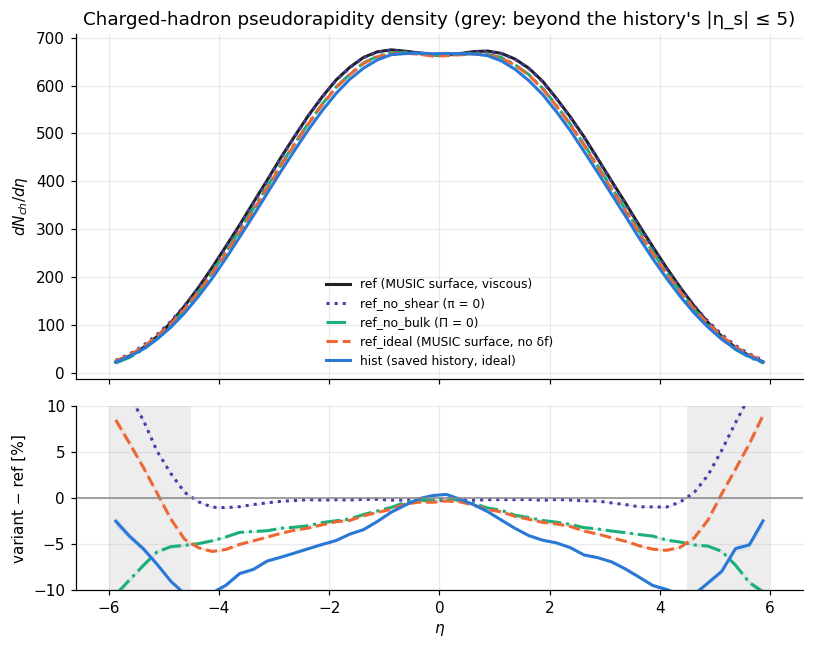

In [4]:
leg = "bg"
x = centers(E["ETA_EDGES"])
fig, ax = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1.6]})
ref = had("ref", leg, "dndeta")
for v in VARIANTS:
    m, e = mean_err(had(v, leg, "dndeta"))
    st = STYLE[v]
    ax[0].plot(x, m / np.diff(E["ETA_EDGES"]), color=st["color"], ls=st["ls"], label=st["label"])
    if v != "ref":
        r, re = rel_shift(had(v, leg, "dndeta"), ref)
        ax[1].plot(x, 100 * r, color=st["color"], ls=st["ls"])
        ax[1].fill_between(x, 100 * (r - re), 100 * (r + re), color=st["color"], alpha=0.2, lw=0)
ax[0].set_ylabel(r"$dN_{ch}/d\eta$")
ax[0].legend(fontsize=8)
ax[1].axhline(0, color="#888888", lw=1)
ax[1].axvspan(-6, -4.5, color="#dddddd", alpha=0.5, lw=0); ax[1].axvspan(4.5, 6, color="#dddddd", alpha=0.5, lw=0)
ax[1].set_ylim(-10, 10)
ax[1].set_ylabel("variant − ref [%]")
ax[1].set_xlabel(r"$\eta$")
ax[0].set_title("Charged-hadron pseudorapidity density (grey: beyond the history's |η_s| ≤ 5)")
fig.tight_layout(); plt.show()

In [5]:
import pandas as pd

SPEC = {"π": (0, 1), "K": (2, 3), "p": (4, 5)}
def yields(v, leg):
    d = had(v, leg, "dndy")
    return {s: d[:, list(i)].sum(1) for s, i in SPEC.items()}
def meanpt(v, leg):
    d, sp = had(v, leg, "dndy"), had(v, leg, "sumpt")
    return {s: sp[:, list(i)].sum(1) / d[:, list(i)].sum(1) for s, i in SPEC.items()}
def dnch(v, leg):
    ed = E["ETA_EDGES"]; c = centers(ed)
    return had(v, leg, "dndeta")[:, np.abs(c) < 0.5].sum(1) / 1.0

def table(leg):
    rows = []
    Yr, Pr, Nr = yields("ref", leg), meanpt("ref", leg), dnch("ref", leg)
    for v in VARIANTS:
        Y, P, N = yields(v, leg), meanpt(v, leg), dnch(v, leg)
        row = {"variant": v}
        m, e = mean_err(N); row["dNch/dη |η|<.5"] = f"{m:.1f}"
        for s in SPEC:
            m, e = mean_err(P[s]); row[f"<pT> {s} [GeV]"] = f"{m:.4f}"
        if v != "ref":
            r, e = rel_shift(N, Nr); row["Δ dNch/dη"] = f"{100*r:+.2f} ± {100*e:.2f} %"
            for s in SPEC:
                r, e = rel_shift(Y[s], Yr[s]); row[f"Δ dN/dy {s}"] = f"{100*r:+.2f} ± {100*e:.2f} %"
            for s in SPEC:
                r, e = rel_shift(P[s], Pr[s]); row[f"Δ<pT> {s}"] = f"{100*r:+.2f} ± {100*e:.2f} %"
        rows.append(row)
    return pd.DataFrame(rows).set_index("variant").fillna("")

print("background leg (|y| < 0.5 for identified; shifts relative to ref, event by event)")
display(table("bg"))

background leg (|y| < 0.5 for identified; shifts relative to ref, event by event)


,dNch/dη |η|<.5,<pT> π [GeV],<pT> K [GeV],<pT> p [GeV],Δ dNch/dη,Δ dN/dy π,Δ dN/dy K,Δ dN/dy p,Δ<pT> π,Δ<pT> K,Δ<pT> p
variant,,,,,,,,,,,
ref,666.2,0.4632,0.6693,0.9682,,,,,,,
ref_no_shear,664.8,0.4543,0.6545,0.9526,-0.20 ± 0.01 %,-0.02 ± 0.01 %,+0.02 ± 0.03 %,+0.03 ± 0.03 %,-1.91 ± 0.02 %,-2.22 ± 0.03 %,-1.62 ± 0.03 %
ref_no_bulk,665.1,0.5358,0.7762,1.0673,-0.16 ± 0.03 %,+0.06 ± 0.03 %,+1.75 ± 0.06 %,-29.34 ± 0.33 %,+15.68 ± 0.07 %,+15.96 ± 0.09 %,+10.23 ± 0.11 %
ref_ideal,663.6,0.5257,0.7588,1.0415,-0.38 ± 0.03 %,+0.03 ± 0.03 %,+1.75 ± 0.06 %,-29.34 ± 0.33 %,+13.50 ± 0.07 %,+13.36 ± 0.08 %,+7.57 ± 0.09 %
hist,667.1,0.5193,0.7467,1.0224,+0.15 ± 0.04 %,+0.66 ± 0.04 %,+2.74 ± 0.08 %,-28.62 ± 0.33 %,+12.12 ± 0.06 %,+11.55 ± 0.08 %,+5.59 ± 0.09 %


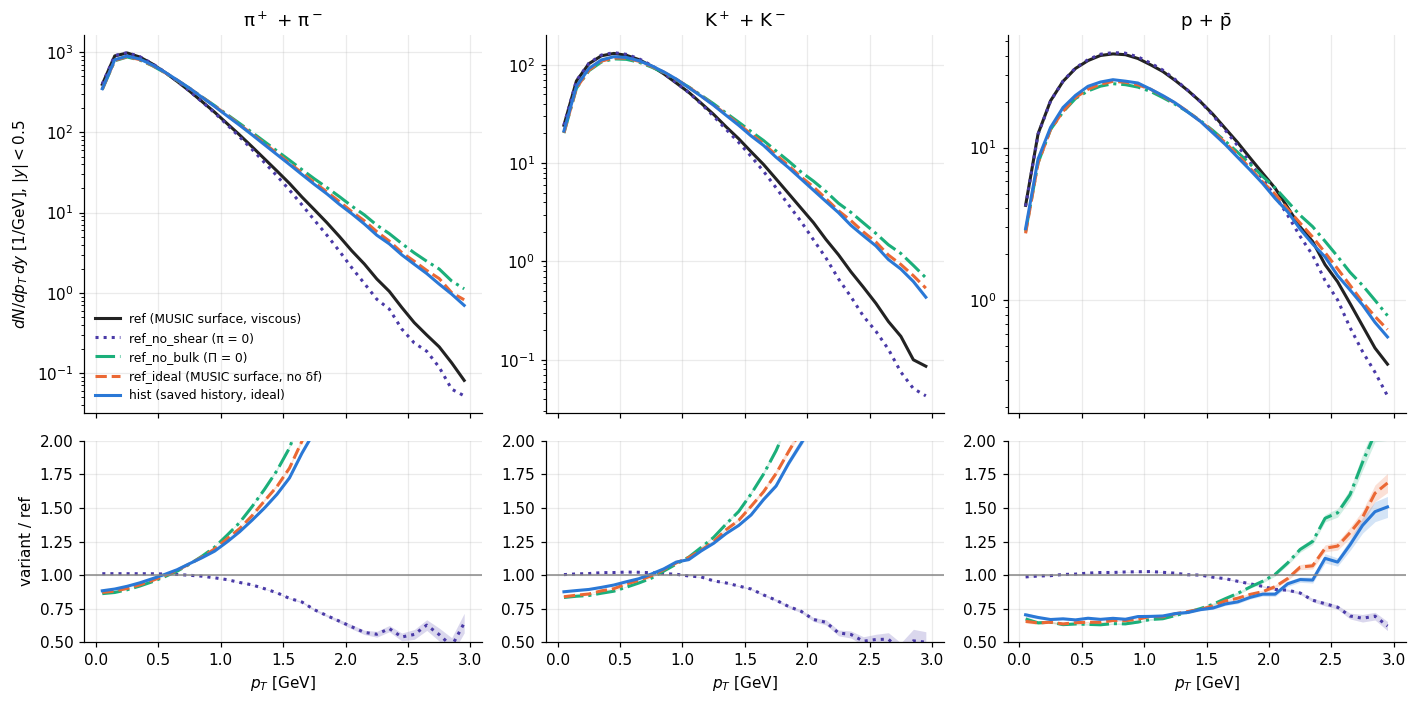

In [6]:
fig, ax = plt.subplots(2, 3, figsize=(13, 6.5), sharex=True, gridspec_kw={"height_ratios": [3, 1.6]})
x = centers(E["PT_EDGES"])
for j, s in enumerate(("π", "K", "p")):
    ref = had("ref", leg, "ptspec")[:, j]
    for v in VARIANTS:
        d = had(v, leg, "ptspec")[:, j]
        m, _ = mean_err(d)
        st = STYLE[v]
        ax[0, j].semilogy(x, m, color=st["color"], ls=st["ls"], label=st["label"])
        if v != "ref":
            r, re = rel_shift(d, ref)
            ax[1, j].plot(x, 1 + r, color=st["color"], ls=st["ls"])
            ax[1, j].fill_between(x, 1 + r - re, 1 + r + re, color=st["color"], alpha=0.2, lw=0)
    ax[0, j].set_title(f"{s}$^+$ + {s}$^-$" if s != "p" else "p + p̄")
    ax[1, j].axhline(1, color="#888888", lw=1)
    ax[1, j].set_ylim(0.5, 2.0)
    ax[1, j].set_xlabel(r"$p_T$ [GeV]")
ax[0, 0].set_ylabel(r"$dN/dp_T\,dy$ [1/GeV], $|y|<0.5$")
ax[1, 0].set_ylabel("variant / ref")
ax[0, 0].legend(fontsize=8)
fig.tight_layout(); plt.show()

## 3. Anisotropic flow

$v_n\{2\}$ per event from the flow vectors of charged hadrons at $|\eta|<1$, with all
oversamples of the event pooled and self-pairs removed:
$c_n = (|Q_n|^2 - N)/(N(N-1))$, $d_n(p_T) = (\mathrm{Re}\,Q_n(p_T)Q_n^* - N(p_T))/(N(p_T)(N-1))$,
$v_n\{2\}(p_T) = \langle d_n\rangle/\sqrt{\langle c_n\rangle}$ averaged over events.
Pairs across oversamples are pure flow of that event's fluid; pairs inside one oversample
(1/N_samples of all pairs) add the decay non-flow, the same for every variant.

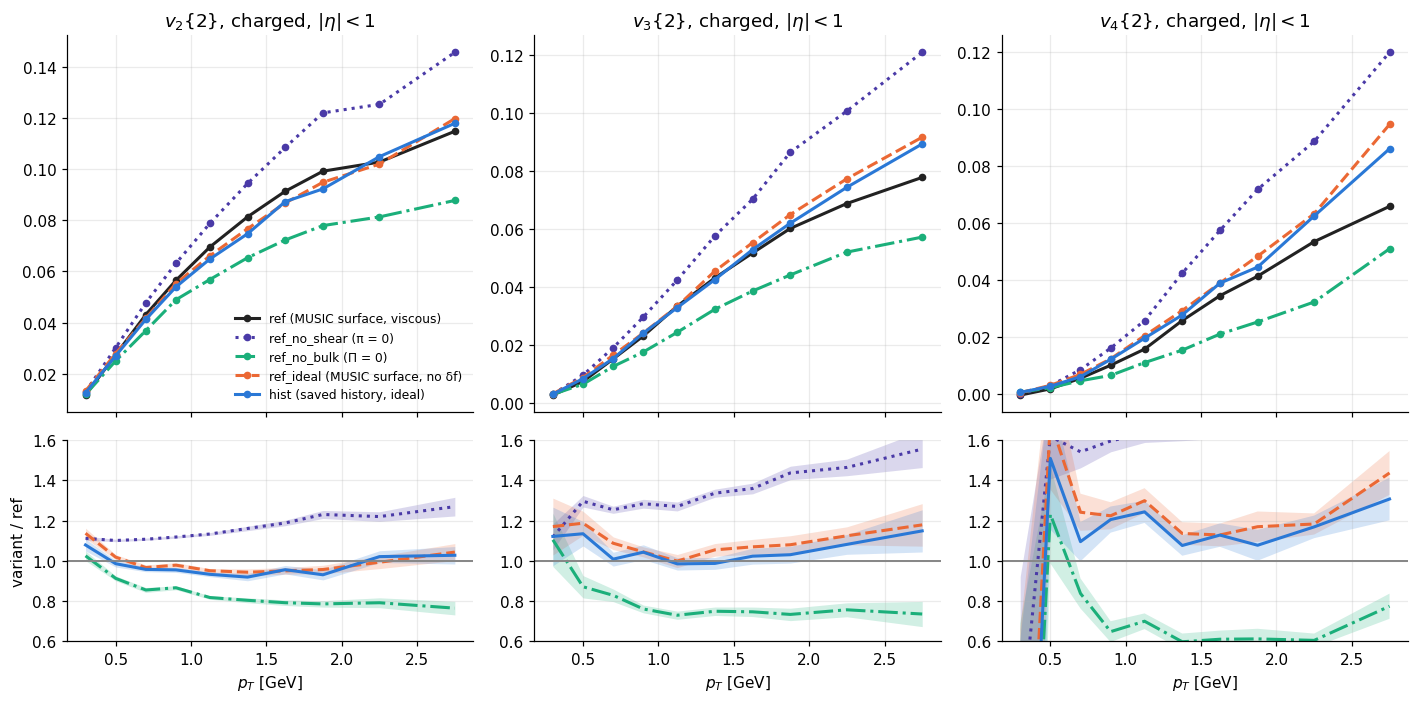

,v2{2} int,v3{2} int,v4{2} int,Δv2 (event by event),Δv3 (event by event),Δv4 (event by event)
variant,,,,,,
ref,0.0362,0.0143,0.0062,,,
ref_no_shear,0.0400,0.0178,0.0098,+10.31 ± 0.71 %,+24.55 ± 2.05 %,+67.47 ± 4.22 %
ref_no_bulk,0.0342,0.0130,0.0057,-5.48 ± 0.56 %,-8.92 ± 1.48 %,-8.69 ± 3.57 %
ref_ideal,0.0387,0.0173,0.0095,+6.50 ± 0.85 %,+21.37 ± 2.42 %,+59.78 ± 5.69 %
hist,0.0374,0.0163,0.0088,+3.27 ± 0.72 %,+15.44 ± 2.06 %,+47.51 ± 5.02 %


In [7]:
def flow(v, leg):
    ns = had(v, leg, "n_samples")[:, None]
    Q = had(v, leg, "Q") * ns[:, :, None]          # (event, n, bin); last bin = integrated
    N = had(v, leg, "NQ") * ns                      # (event, bin)
    Qi, Ni = Q[:, :, -1], N[:, -1]
    c = (np.abs(Qi) ** 2 - Ni[:, None]) / (Ni * (Ni - 1))[:, None]           # (event, n)
    d = ((Q[:, :, :-1] * np.conj(Qi)[:, :, None]).real - N[:, None, :-1]) / \
        (N[:, None, :-1] * (Ni[:, None, None] - 1))                         # (event, n, pT)
    return c, d

def vn_int(c):   # per-event integrated v_n{2} (for event-by-event comparisons)
    return np.sqrt(np.clip(c, 0, None))

x = centers(E["PTV_EDGES"])
fig, ax = plt.subplots(2, 3, figsize=(13, 6.5), sharex=True, gridspec_kw={"height_ratios": [3, 1.6]})
c_ref, d_ref = flow("ref", leg)
vref = {n: d_ref[:, n - 1].mean(0) / np.sqrt(c_ref[:, n - 1].mean()) for n in (2, 3, 4)}
for v in VARIANTS:
    c, d = flow(v, leg)
    st = STYLE[v]
    for j, n in enumerate((2, 3, 4)):
        vn = d[:, n - 1].mean(0) / np.sqrt(c[:, n - 1].mean())
        # jackknife over events for the ratio's error
        jk = []
        for k in range(len(c)):
            m = np.ones(len(c), bool); m[k] = False
            a = d[m, n - 1].mean(0) / np.sqrt(c[m, n - 1].mean())
            b = d_ref[m, n - 1].mean(0) / np.sqrt(c_ref[m, n - 1].mean())
            jk.append(a / b)
        jk = np.array(jk); r = vn / vref[n]
        re = np.sqrt((len(jk) - 1) * np.var(jk, axis=0))
        ax[0, j].plot(x, vn, color=st["color"], ls=st["ls"], marker="o", ms=4, label=st["label"])
        if v != "ref":
            ax[1, j].plot(x, r, color=st["color"], ls=st["ls"])
            ax[1, j].fill_between(x, r - re, r + re, color=st["color"], alpha=0.2, lw=0)
        ax[0, j].set_title(f"$v_{n}\\{{2\\}}$, charged, $|\\eta|<1$")
        ax[1, j].axhline(1, color="#888888", lw=1); ax[1, j].set_ylim(0.6, 1.6)
        ax[1, j].set_xlabel(r"$p_T$ [GeV]")
ax[1, 0].set_ylabel("variant / ref")
ax[0, 0].legend(fontsize=8)
fig.tight_layout(); plt.show()

rows = []
for v in VARIANTS:
    c, _ = flow(v, leg)
    row = {"variant": v}
    for n in (2, 3, 4):
        vn = np.sqrt(c[:, n - 1].mean()); row[f"v{n}{{2}} int"] = f"{vn:.4f}"
        if v != "ref":
            r, e = rel_shift(vn_int(c[:, n - 1]), vn_int(c_ref[:, n - 1]))
            row[f"Δv{n} (event by event)"] = f"{100*r:+.2f} ± {100*e:.2f} %"
    rows.append(row)
display(pd.DataFrame(rows).set_index("variant").fillna(""))

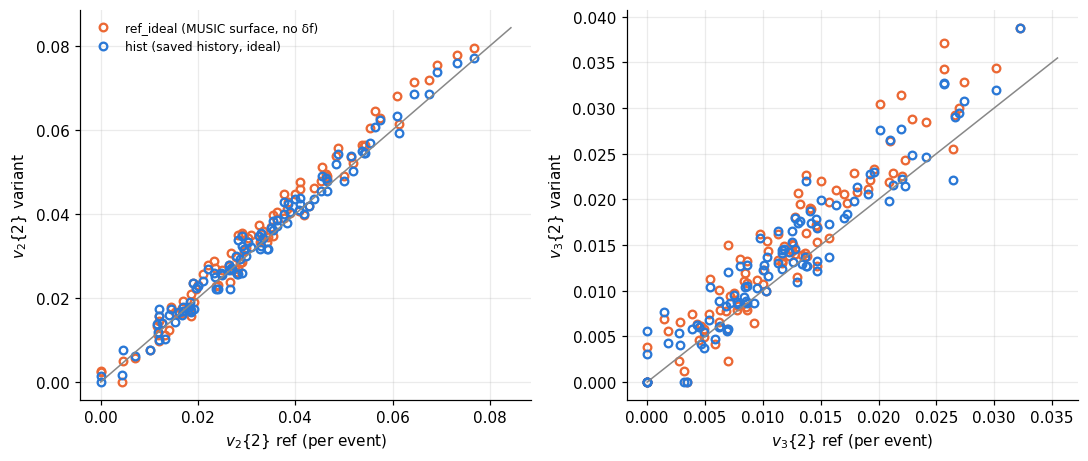

In [8]:
# event by event: does the history reproduce each event's flow?
fig, ax = plt.subplots(1, 2, figsize=(10, 4.3))
c_h, _ = flow("hist", leg); c_i, _ = flow("ref_ideal", leg)
for j, n in enumerate((2, 3)):
    a = vn_int(c_ref[:, n - 1])
    for v, cv in (("ref_ideal", c_i), ("hist", c_h)):
        st = STYLE[v]
        ax[j].plot(a, vn_int(cv[:, n - 1]), "o", ms=5, mfc="none", mew=1.5, color=st["color"], label=st["label"])
    lim = [0, 1.1 * a.max()]
    ax[j].plot(lim, lim, color="#888888", lw=1)
    ax[j].set_xlabel(f"$v_{n}\\{{2\\}}$ ref (per event)"); ax[j].set_ylabel(f"$v_{n}\\{{2\\}}$ variant")
ax[0].legend(fontsize=8)
fig.tight_layout(); plt.show()

## 4. Where the difference comes from

Relative shifts of the key bulk observables along the chain, event by event: the viscous
corrections (shear, bulk, both) on MUSIC's own surface, then the history on top of the ideal
Cooper–Frye. `hist − ref` is the total.

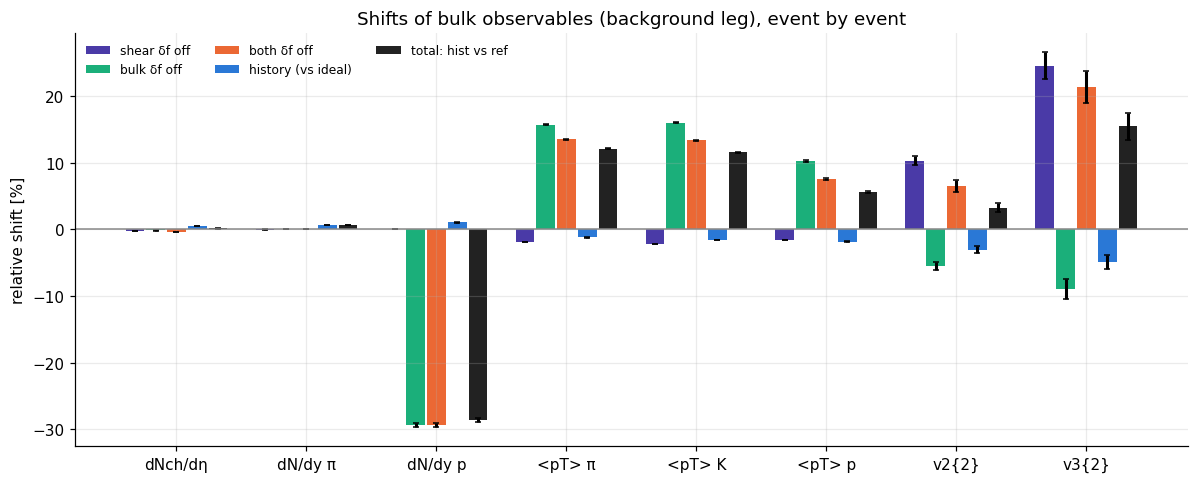

,shear δf off,bulk δf off,both δf off,history (vs ideal),total: hist vs ref
dNch/dη,-0.20 ± 0.01,-0.16 ± 0.03,-0.38 ± 0.03,+0.53 ± 0.03,+0.15 ± 0.04
dN/dy π,-0.02 ± 0.01,+0.06 ± 0.03,+0.03 ± 0.03,+0.63 ± 0.03,+0.66 ± 0.04
dN/dy p,+0.03 ± 0.03,-29.34 ± 0.33,-29.34 ± 0.33,+1.03 ± 0.11,-28.62 ± 0.33
<pT> π,-1.91 ± 0.02,+15.68 ± 0.07,+13.50 ± 0.07,-1.21 ± 0.03,+12.12 ± 0.06
<pT> K,-2.22 ± 0.03,+15.96 ± 0.09,+13.36 ± 0.08,-1.60 ± 0.05,+11.55 ± 0.08
<pT> p,-1.62 ± 0.03,+10.23 ± 0.11,+7.57 ± 0.09,-1.84 ± 0.07,+5.59 ± 0.09
v2{2},+10.31 ± 0.71,-5.48 ± 0.56,+6.50 ± 0.85,-3.03 ± 0.47,+3.27 ± 0.72
v3{2},+24.55 ± 2.05,-8.92 ± 1.48,+21.37 ± 2.42,-4.88 ± 1.05,+15.44 ± 2.06


In [9]:
def observables(v, leg):
    P, Y, (c, _) = meanpt(v, leg), yields(v, leg), flow(v, leg)
    return {"dNch/dη": dnch(v, leg), "dN/dy π": Y["π"], "dN/dy p": Y["p"],
            "<pT> π": P["π"], "<pT> K": P["K"], "<pT> p": P["p"],
            "v2{2}": vn_int(c[:, 1]), "v3{2}": vn_int(c[:, 2])}

STEPS = [("ref_no_shear", "ref", "shear δf off"), ("ref_no_bulk", "ref", "bulk δf off"),
         ("ref_ideal", "ref", "both δf off"), ("hist", "ref_ideal", "history (vs ideal)"),
         ("hist", "ref", "total: hist vs ref")]
STEPS = [s for s in STEPS if s[0] in VARIANTS and s[1] in VARIANTS]
obs = {v: observables(v, leg) for v in VARIANTS}
names = list(obs["ref"])
shift = {lab: [rel_shift(obs[a][k], obs[b][k]) for k in names] for a, b, lab in STEPS}

fig, ax = plt.subplots(figsize=(11, 4.5))
w = 0.8 / len(STEPS)
step_color = {"shear δf off": STYLE["ref_no_shear"]["color"], "bulk δf off": STYLE["ref_no_bulk"]["color"],
              "both δf off": STYLE["ref_ideal"]["color"], "history (vs ideal)": STYLE["hist"]["color"],
              "total: hist vs ref": "#222222"}
for i, (a, b, lab) in enumerate(STEPS):
    m = np.array([100 * s[0] for s in shift[lab]]); e = np.array([100 * s[1] for s in shift[lab]])
    ax.bar(np.arange(len(names)) + (i - (len(STEPS) - 1) / 2) * w, m, w * 0.9, yerr=e,
           color=step_color[lab], label=lab, capsize=2)
ax.axhline(0, color="#888888", lw=1)
ax.set_xticks(np.arange(len(names))); ax.set_xticklabels(names)
ax.set_ylabel("relative shift [%]")
ax.legend(ncol=3, fontsize=8)
ax.set_title("Shifts of bulk observables (background leg), event by event")
fig.tight_layout(); plt.show()

display(pd.DataFrame({lab: [f"{100*m:+.2f} ± {100*e:.2f}" for m, e in shift[lab]] for _, _, lab in STEPS},
                     index=names))

## 5. The jet wake: jet leg − background

What the pair files are for: the jet's effect on the medium, here at hadron level. Soft
charged hadrons ($p_T<4$ GeV, $|\eta - y_{jet}|<1$) per event, jet leg minus its own
background, as a function of $\Delta\phi$ to the jet axis (the hardest shower initiator),
and the near-side ($|\Delta\phi|<1$) $p_T$ spectrum. Bulk only: the jet's own fragments
(`jet_frag`) are identical in all variants.

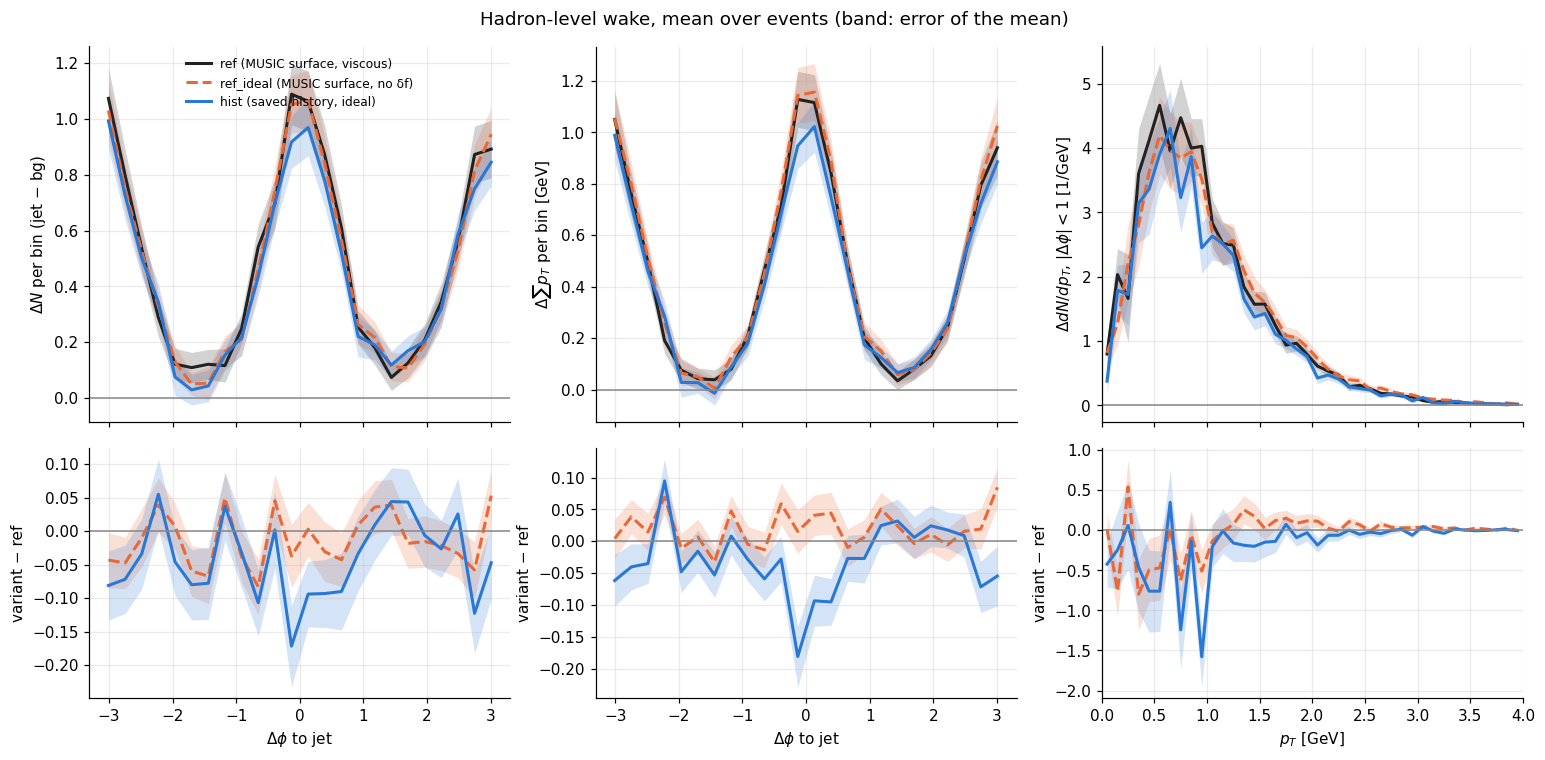

variant,ref,ref_ideal,hist
ΔN near,+5.37 ± 0.55,+5.20 ± 0.52,+4.76 ± 0.51
ΔN away,+5.37 ± 0.57,+5.25 ± 0.52,+5.07 ± 0.50
ΔΣpT near [GeV],+5.17 ± 0.48,+5.30 ± 0.46,+4.63 ± 0.44
ΔΣpT away [GeV],+4.98 ± 0.51,+5.22 ± 0.51,+4.84 ± 0.46
ΔE |η|<1 [GeV],+23.99 ± 1.23,+24.13 ± 1.21,+21.52 ± 1.06
ΔN near − ref,,-0.17 ± 0.10,-0.62 ± 0.13
ΔN away − ref,,-0.12 ± 0.10,-0.30 ± 0.15
ΔΣpT near [GeV] − ref,,+0.14 ± 0.07,-0.54 ± 0.10
ΔΣpT away [GeV] − ref,,+0.24 ± 0.07,-0.14 ± 0.12
ΔE |η|<1 [GeV] − ref,,+0.14 ± 0.21,-2.47 ± 0.33


In [10]:
WAKE_VARIANTS = [v for v in ("ref", "ref_ideal", "hist") if v in VARIANTS]
def wake(v, name):
    return had(v, "jet", name) - had(v, "bg", name)

x = centers(E["DPHI_EDGES"])
xp = centers(E["PTCH_EDGES"])
fig, ax = plt.subplots(2, 3, figsize=(14, 7), sharex="col", gridspec_kw={"height_ratios": [3, 2]})
PANELS = (("dphi_jet", x), ("dphi_jet_pt", x), ("pt_near", xp))
for v in WAKE_VARIANTS:
    st = STYLE[v]
    for j, (name, xx) in enumerate(PANELS):
        m, e = mean_err(wake(v, name))
        ax[0, j].plot(xx, m, color=st["color"], ls=st["ls"], label=st["label"])
        ax[0, j].fill_between(xx, m - e, m + e, color=st["color"], alpha=0.2, lw=0)
        if v != "ref":       # the change of the wake, event by event
            m, e = mean_err(wake(v, name) - wake("ref", name))
            ax[1, j].plot(xx, m, color=st["color"], ls=st["ls"])
            ax[1, j].fill_between(xx, m - e, m + e, color=st["color"], alpha=0.2, lw=0)
for a in ax.ravel(): a.axhline(0, color="#888888", lw=1)
ax[0, 0].set_ylabel(r"$\Delta N$ per bin (jet − bg)")
ax[0, 1].set_ylabel(r"$\Delta \sum p_T$ per bin [GeV]")
ax[0, 2].set_ylabel(r"$\Delta dN/dp_T$, $|\Delta\phi|<1$ [1/GeV]")
for j in range(3): ax[1, j].set_ylabel("variant − ref")
ax[1, 0].set_xlabel(r"$\Delta\phi$ to jet"); ax[1, 1].set_xlabel(r"$\Delta\phi$ to jet")
ax[1, 2].set_xlabel(r"$p_T$ [GeV]"); ax[1, 2].set_xlim(0, 4)
ax[0, 0].legend(fontsize=8)
fig.suptitle("Hadron-level wake, mean over events (band: error of the mean)")
fig.tight_layout(); plt.show()

# integrated wake numbers and their difference to ref, event by event
rows = []
near = np.abs(x) < 1; away = np.abs(x) > np.pi - 1
Q = {"ΔN near": lambda v: wake(v, "dphi_jet")[:, near].sum(1),
     "ΔN away": lambda v: wake(v, "dphi_jet")[:, away].sum(1),
     "ΔΣpT near [GeV]": lambda v: wake(v, "dphi_jet_pt")[:, near].sum(1),
     "ΔΣpT away [GeV]": lambda v: wake(v, "dphi_jet_pt")[:, away].sum(1),
     "ΔE |η|<1 [GeV]": lambda v: wake(v, "E_eta1")}
for v in WAKE_VARIANTS:
    row = {"variant": v}
    for k, f in Q.items():
        m, e = mean_err(f(v)); row[k] = f"{m:+.2f} ± {e:.2f}"
        if v != "ref":
            d, de = mean_err(f(v) - f("ref")); row[f"{k} − ref"] = f"{d:+.2f} ± {de:.2f}"
    rows.append(row)
display(pd.DataFrame(rows).set_index("variant").fillna("").T)

Where does the difference in the wake come from? The jet-induced freeze-out volume
(jet-leg surface − background surface) is already there before any hadron, and the
event-by-event ratio shows whether `hist` distorts the wake or scales it.

ref   jet-induced freeze-out volume   65.03 ± 2.66 fm^3  (of 19672)
hist  jet-induced freeze-out volume   61.56 ± 2.46 fm^3  (of 19296)
      hist / ref per event: median 0.951
ref_ideal  wake energy |η|<1: ratio to ref per event, median 1.016, correlation 0.986;  all η: 32.88 vs ref 32.78 GeV
hist       wake energy |η|<1: ratio to ref per event, median 0.898, correlation 0.968;  all η: 31.50 vs ref 32.78 GeV


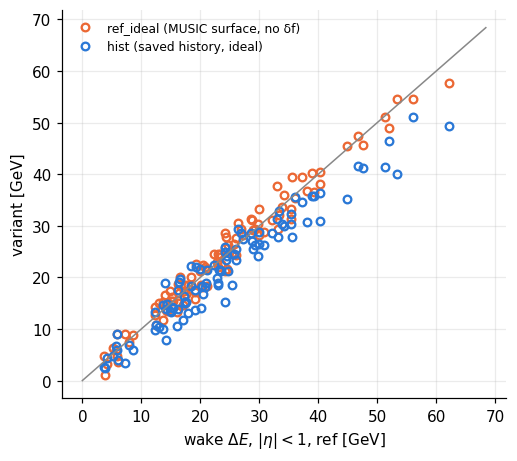

In [11]:
if "surf/hist/jet/V" in S.files:
    for v in ("ref", "hist"):
        dV = surf(v, "jet", "V") - surf(v, "bg", "V")
        m, e = mean_err(dV)
        print(f"{v:5s} jet-induced freeze-out volume  {m:6.2f} ± {e:.2f} fm^3  "
              f"(of {surf(v, 'bg', 'V').mean():.0f})")
    r = (surf("hist", "jet", "V") - surf("hist", "bg", "V")) / (surf("ref", "jet", "V") - surf("ref", "bg", "V"))
    print(f"      hist / ref per event: median {np.median(r):.3f}")
wE = {v: had(v, "jet", "E_eta1") - had(v, "bg", "E_eta1") for v in WAKE_VARIANTS}
wA = {v: had(v, "jet", "E_all") - had(v, "bg", "E_all") for v in WAKE_VARIANTS}
for v in WAKE_VARIANTS:
    if v == "ref":
        continue
    print(f"{v:10s} wake energy |η|<1: ratio to ref per event, median {np.median(wE[v] / wE['ref']):.3f}, "
          f"correlation {np.corrcoef(wE[v], wE['ref'])[0, 1]:.3f};  all η: "
          f"{wA[v].mean():.2f} vs ref {wA['ref'].mean():.2f} GeV")
fig, ax = plt.subplots(figsize=(4.8, 4.3))
for v in [w for w in WAKE_VARIANTS if w != "ref"]:
    st = STYLE[v]
    ax.plot(wE["ref"], wE[v], "o", ms=5, mfc="none", mew=1.5, color=st["color"], label=st["label"])
lim = [min(0, wE["ref"].min()), 1.1 * wE["ref"].max()]
ax.plot(lim, lim, color="#888888", lw=1)
ax.set_xlabel(r"wake $\Delta E$, $|\eta|<1$, ref [GeV]"); ax.set_ylabel("variant [GeV]")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## 6. Findings

The numbers quoted here are from the run this notebook was executed on (100 events, 4
production files of `AuAu_0_10_h5_pair_surface_test`, 100 iSS oversamples each); re-running
on other data updates the tables and figures above, not this text.

All shifts are event by event relative to `ref`, for the background leg at mid-rapidity
(the jet leg is the same within errors). The errors are statistical, over 100 events.

**Surfaces agree to 2%.** The surface found in the history has 70% of MUSIC's cells (a
coarser lattice) and 0.981 of its freeze-out volume, in every event (0.980–0.982). Its
position and timing match: dV/dτ agrees within 2–3% from τ ≈ 1.5 to 9 fm/c. It has less
of the fastest fluid, though: dV/du_T falls below the reference above u_T ≈ 0.7 and is
20% low at u_T = 0.9. MUSIC's surface carries a bulk pressure ⟨Π⟩/(e+P) = −0.046 and a
shear stress ⟨√(π:π)⟩/(e+P) = 0.028, which `hist` does not have.

**Bulk hadrons: the missing viscous corrections dominate, not the coarse history.**

| observable | shear δf off | bulk δf off | both off (`ref_ideal`) | history on top (`hist` − `ref_ideal`) | **total (`hist` − `ref`)** |
|---|---|---|---|---|---|
| dN_ch/dη, \\|η\\|<0.5 | −0.2% | −0.2% | −0.4% | +0.5% | **+0.2%** |
| dN/dy p + p̄ | 0.0% | −29.3% | −29.3% | +1.0% | **−28.6%** |
| ⟨pT⟩ π | −1.9% | +15.7% | +13.5% | −1.2% | **+12.1%** |
| ⟨pT⟩ K | −2.2% | +16.0% | +13.4% | −1.6% | **+11.6%** |
| ⟨pT⟩ p | −1.6% | +10.2% | +7.6% | −1.8% | **+5.6%** |
| v₂{2} | +10.3% | −5.5% | +6.5% | −3.0% | **+3.3%** |
| v₃{2} | +24.6% | −8.9% | +21.4% | −4.9% | **+15.4%** |

- The statistical errors are 0.01–0.3% for yields and ⟨pT⟩, and 0.5–2.4% for v_n.
- **Bulk δf** sets the yields and the spectral shape. Without it, protons drop by 29%
  and the spectra harden (⟨pT⟩ +10–16%).
- **Shear δf** sets the flow harmonics. Without it, v₂, v₃ and v₄ rise by 10%, 25% and
  67%, increasingly with pT.
- **The coarse history** adds only 0.5–2% to yields and ⟨pT⟩, and 3–5% to v_n (lower,
  consistent with the missing fast fluid). It partly offsets the viscous shifts.
- The total hadron energy is not the same with and without δf. Over all rapidities it is
  +3.9% for `ref_ideal` over `ref`, and +4.9% at |η| < 1: iSS's viscous corrections, as
  applied here, do not conserve energy.
- Over all rapidities `hist` has 6% less energy than `ref_ideal`. That is the forward
  region beyond the history's |η_s| = 5; at |η| < 1 the difference is −1.1%.

**Jet wake (jet − background): δf cancels, the history loses about 10%.**
- ΔE (|η| < 1) of the soft bulk:
  - `ref`: 24.0 ± 1.2 GeV;
  - `ref_ideal`: +0.14 ± 0.21 GeV relative to `ref`. The viscous corrections do not matter
    for the wake at this precision.
  - `hist`: 21.5 ± 1.1 GeV, i.e. −2.47 ± 0.33 GeV (−10%) relative to `ref`.
- On the near side (|Δφ| < 1, soft charged) `hist` has −12 ± 2% fewer hadrons and
  −10 ± 2% less pT; the away-side deficit is smaller. Over all rapidities the wake
  energy is −4%.
- The deficit is a **scale, not a distortion**. Per event, hist's wake is highly
  correlated with ref's (r = 0.97), with a median ratio of 0.90, and the Δφ shape is the
  same.
- It is already in the surfaces: the jet-induced freeze-out volume is 61.6 vs
  65.0 fm³ (−5%).
- Likely cause: the wake is small and fast, so it suffers most from the resampling onto
  the coarser output grid (0.2 → 0.3125 in η_s) and from the reduced flow at the fireball
  edge. This is not pinned down (see *Next steps*).

**What this means for hadronizing an FNO history.**
- dN/dη and the wake's shape can be taken from the history as it is. The wake's size comes
  out about 10% low.
- Spectra, identified yields, ⟨pT⟩ and v_n cannot. The error there is 5–30%, and almost
  all of it is the missing δf, bulk for yields and ⟨pT⟩, shear for v_n.

**Next steps** (README): restore δf from the stored gradients (Navier–Stokes) or store Π in the pair files; run `hist` on a native-grid pair file to pin down the wake deficit; a wider η grid.